In [1]:
# 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: 맑은 고딕
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

# Seaborn 스타일
sns.set_style('whitegrid')

print("환경 설정 완료!")

# 제조 데이터 불러오기
production_df = pd.read_csv('./data/05_production.csv', encoding='utf-8-sig')
sensor_df = pd.read_csv('./data/08_sensor_data.csv', encoding='utf-8-sig')
energy_df = pd.read_csv('./data/09_energy_usage.csv', encoding='utf-8-sig')

# 날짜 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
sensor_df['measurement_time'] = pd.to_datetime(sensor_df['measurement_time'])
energy_df['measurement_time'] = pd.to_datetime(energy_df['measurement_time'])

# 불량률 계산
production_df['defect_rate'] = (
    production_df['defect_quantity'] / production_df['actual_quantity'] * 100
).round(2)

환경 설정 완료!


In [2]:
from koreanize_matplotlib import koreanize
koreanize()

In [3]:
production_df.columns

Index(['production_id', 'equipment_id', 'product_code', 'production_date',
       'start_time', 'end_time', 'target_quantity', 'actual_quantity',
       'good_quantity', 'defect_quantity', 'cycle_time', 'work_order_no',
       'lot_no', 'operator_id', 'shift', 'created_at', 'updated_at',
       'defect_rate'],
      dtype='object')

In [4]:
daily_stats=production_df.groupby('production_date').agg({'actual_quantity':'sum',
                                              'defect_quantity':'sum',
                                              'defect_rate':'mean'}).head(30)

In [5]:
prod_qty=production_df.groupby('product_code')['actual_quantity'].sum()

In [6]:
# 일별  생산 현황 대시보드
# 1. 생산량 추이
# 2. 불량 수 추이
# 3. 일별 평균 불량률
# 4. 제품별 총 생산량

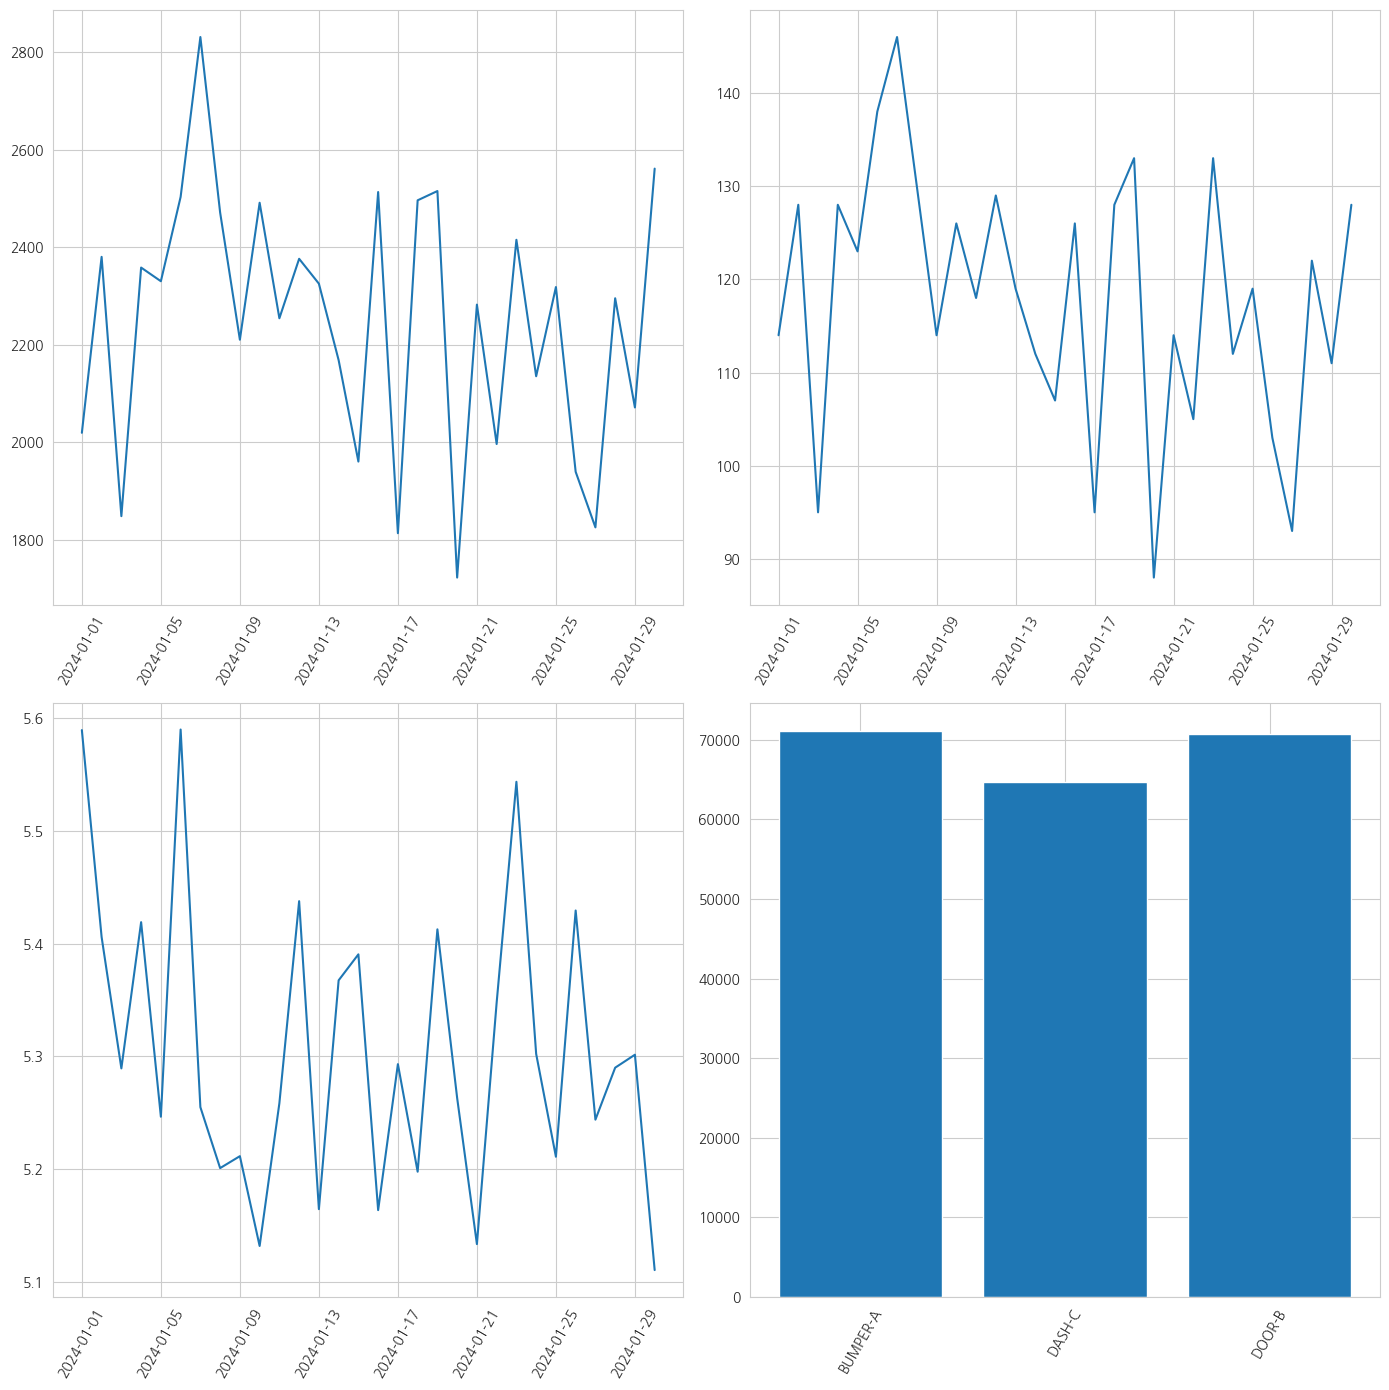

In [7]:
plt.figure(figsize=(14,14))
plt.subplot(2,2,1)
plt.plot(daily_stats.index, daily_stats['actual_quantity'])
plt.xticks(rotation = 60)

plt.subplot(2,2,2)
plt.plot(daily_stats.index, daily_stats['defect_quantity'])
plt.xticks(rotation = 60)

plt.subplot(2,2,3)
plt.plot(daily_stats.index,daily_stats['defect_rate'])
plt.xticks(rotation = 60)

plt.subplot(2,2,4)
plt.bar(prod_qty.index, prod_qty.values)
plt.xticks(rotation = 60)
plt.tight_layout()

plt.show()

In [8]:
# 기본 이중 축
# 왼쪽 y 축은 생산량
# 오른쪽 y 축은 불량률

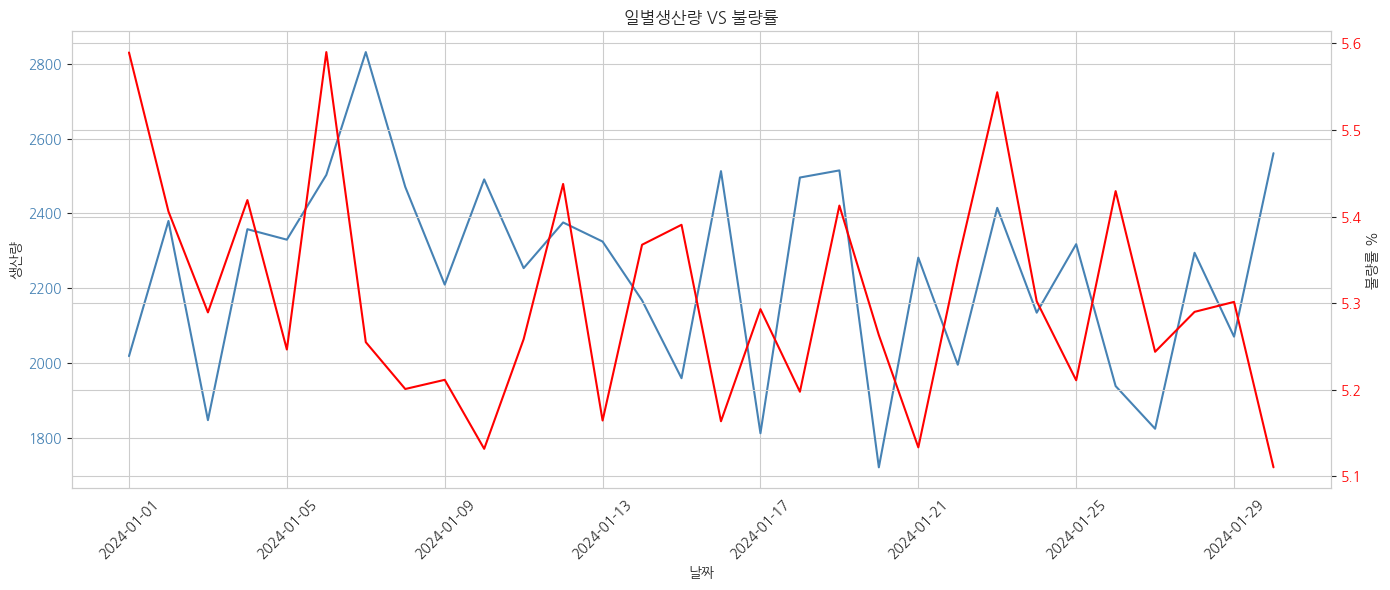

In [11]:
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.set_xlabel('날짜')
ax1.set_ylabel('생산량')
ax1.plot(daily_stats.index,daily_stats['actual_quantity'], color = 'steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation = 45)

ax2 = ax1.twinx()
ax2.set_ylabel('불량률 %')
ax2.plot(daily_stats.index, daily_stats['defect_rate'], color = 'red')
ax2.tick_params(axis='y', labelcolor = 'red')

plt.title('일별생산량 VS 불량률')

plt.tight_layout()
plt.show()

In [14]:
prod_stats=production_df.groupby('product_code').agg({'actual_quantity':'sum',
                                           'defect_rate':'mean'})

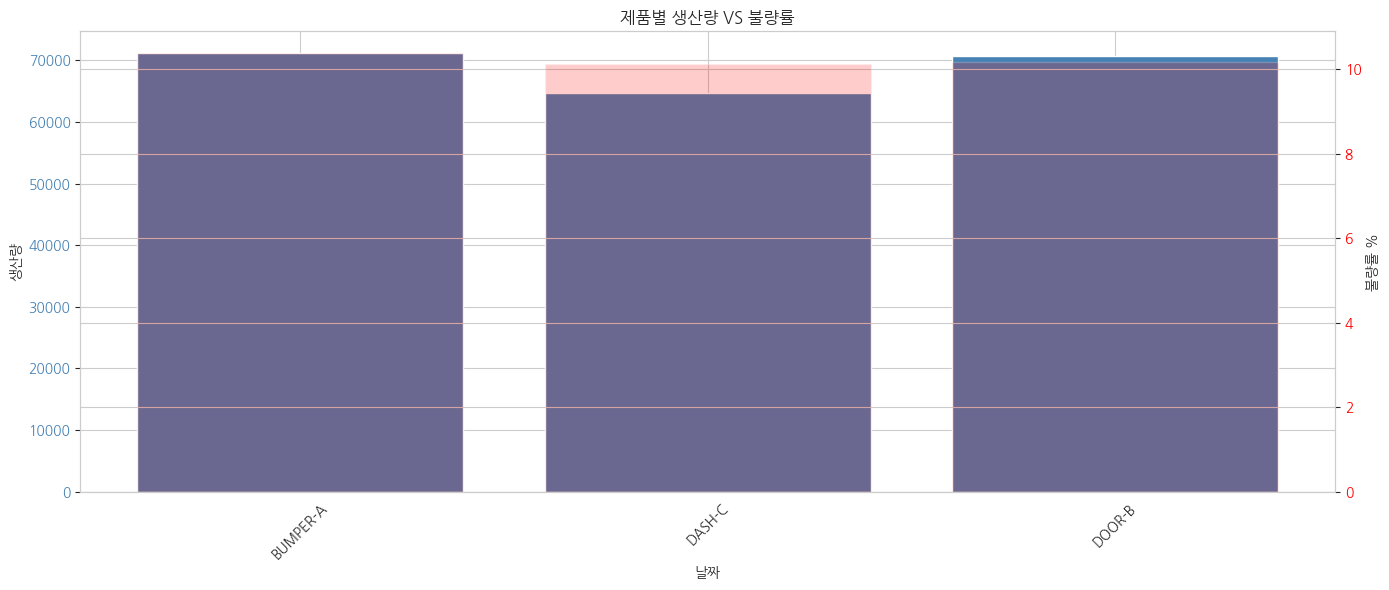

In [19]:
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.set_xlabel('날짜')
ax1.set_ylabel('생산량')
ax1.bar(prod_stats.index,prod_stats['actual_quantity'], color = 'steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation = 45)

ax2 = ax1.twinx()
ax2.set_ylabel('불량률 %')
ax2.bar(prod_stats.index, prod_stats['defect_rate'], color = 'red', alpha= 0.2 )
ax2.tick_params(axis='y', labelcolor = 'red')

plt.title('제품별 생산량 VS 불량률')

plt.tight_layout()
plt.show()

In [20]:
# 일별 불량률 => 이동평균

In [23]:
daily_defect = production_df.groupby('production_date')['defect_rate'].mean()

In [25]:
ma_3 =daily_defect.rolling(window= 3).mean()

In [26]:
ma_7 =daily_defect.rolling(window= 7).mean()

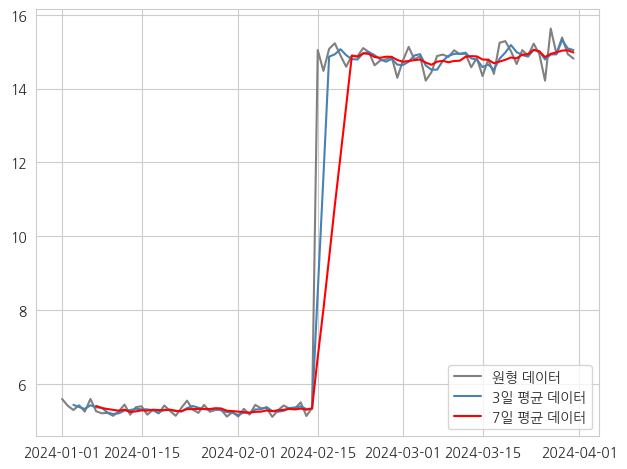

In [36]:
plt.plot(daily_defect.index,daily_defect.values, color ='gray', label = '원형 데이터')
plt.plot(ma_3.index,ma_3.values, color = 'steelblue', label = '3일 평균 데이터')
plt.plot(ma_7.index, ma_7.values, color = 'red',  label = '7일 평균 데이터')
plt.legend( loc= 'lower right')
plt.tight_layout()
plt.show()